# Carlini & Wagner (C&W) Attack

This notebook demonstrates the generation of adversarial examples using the Carlini & Wagner (C&W) $L_2$ attack against pre-trained Convolutional Neural Networks (CNNs). 

Unlike FGSM or PGD, the C&W attack is formulated as an optimization problem. It defines a custom loss function that jointly minimizes the $L_2$ distance between the original and adversarial images, and a misclassification penalty $f(x)$. To strictly enforce valid pixel ranges without clipping (which disrupts gradients), C&W optimizes over a surrogate variable $w$ mapped through a $\tanh$ function.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Import models
from tensorflow.keras.applications import EfficientNetB0, InceptionV3, MobileNetV2

# Import specific preprocessing and decoding functions
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff, decode_predictions as decode_eff
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inc, decode_predictions as decode_inc
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mob, decode_predictions as decode_mob

### Setup Models and Images
We define `box_min` and `box_max` for each model to properly scale the $\tanh$ trick during optimization, ensuring the generated images perfectly respect each model's expected preprocessing boundaries.

In [2]:
# Helper functions for denormalization based on model preprocessing
def denormalize_eff(img):
    # EfficientNet uses [0, 255] range
    img = tf.clip_by_value(img, 0, 255)
    return img.numpy().squeeze().astype("uint8")

def denormalize_neg1_1(img):
    # MobileNetV2 and InceptionV3 use [-1, 1] range
    img = (img + 1.0) / 2.0 # Convert to [0, 1]
    img = img * 255.0 # Convert to [0, 255]
    img = tf.clip_by_value(img, 0, 255)
    return img.numpy().squeeze().astype("uint8")

# Dictionary with model configurations
models_dict = {
    'MobileNetV2': {
        'model': MobileNetV2(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_mob,
        'decode_fn': decode_mob,
        'denormalize_fn': denormalize_neg1_1,
        'box_min': -1.0,
        'box_max': 1.0
    },
    'EfficientNetB0': {
        'model': EfficientNetB0(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_eff,
        'decode_fn': decode_eff,
        'denormalize_fn': denormalize_eff,
        'box_min': 0.0,
        'box_max': 255.0
    },
    'InceptionV3': {
        'model': InceptionV3(weights='imagenet'),
        'target_size': (299, 299),
        'preprocess_fn': preprocess_inc,
        'decode_fn': decode_inc,
        'denormalize_fn': denormalize_neg1_1,
        'box_min': -1.0,
        'box_max': 1.0
    }
}

# Freeze weights as we only need to perform inference and compute gradients w.r.t inputs
for config in models_dict.values():
    config['model'].trainable = False

# Dictionary for target images
images_dict = {
    'Dog': '../../images/dog.png',
    'Lion': '../../images/lion.png'
}

In [3]:
def load_and_preprocess_image(img_path, target_size, preprocess_fn):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, target_size)
    img = preprocess_fn(img) # Dynamic preprocessing
    img = tf.expand_dims(img, axis=0) # Add batch dimension
    return img

def get_imagenet_label(prob, decode_fn):
    return decode_fn(prob, top=1)[0][0] 

def get_imagenet_class_index(prob):
    return tf.argmax(prob, axis=-1).numpy()[0]

def euclidean_distance(img1, img2):
    return np.linalg.norm(img1.numpy() - img2.numpy())

### Carlini & Wagner Optimization
Instead of optimizing the pixels directly, we optimize a variable $w$ and compute the adversarial image as:
$$x_{adv} = \frac{1}{2}(\tanh(w) + 1)$$
This is then scaled to the target `[box_min, box_max]` range. The loss function is:
$$\min_w ||x_{adv} - x||_2^2 + c \cdot f(x_{adv})$$
Where $c$ controls the trade-off, and $f(x)$ ensures the target probability is minimized while another class probability is maximized.

In [4]:
def cw_attack(input_image, input_label, current_model, box_min, box_max, c_weight=1.0, learning_rate=0.01, max_iters=200):
    
    # Initialize the modifier variable 'w' with zeros
    modifier = tf.Variable(tf.zeros(shape=input_image.shape, dtype=tf.float32))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    for i in range(max_iters):
        with tf.GradientTape() as tape:
            # Tanh transformation: scales [-inf, inf] to [0, 1]
            adv_image_normalized = 0.5 * (tf.tanh(modifier) + 1.0)
            
            # Scale to the model's specific bounding box range
            adv_image = adv_image_normalized * (box_max - box_min) + box_min
            
            # Calculate L2 distance loss
            l2_loss = tf.reduce_sum(tf.square(adv_image - input_image))
            
            # Calculate C&W misclassification loss f(x)
            predictions = current_model(adv_image)
            
            # Probabilities of the true class vs the highest other class
            real_class_prob = tf.reduce_sum(input_label * predictions, axis=1)
            other_class_prob = tf.reduce_max((1.0 - input_label) * predictions, axis=1)
            
            # We want to minimize real_class_prob and maximize other_class_prob
            f_loss = tf.maximum(0.0, real_class_prob - other_class_prob) # f(x) = max(real - other, 0)
            
            # Total combined loss
            total_loss = l2_loss + c_weight * f_loss
            
        # Apply gradients to the modifier 'w'
        gradients = tape.gradient(total_loss, [modifier])
        optimizer.apply_gradients(zip(gradients, [modifier]))
        
    # Generate the final image after optimization
    final_adv_normalized = 0.5 * (tf.tanh(modifier) + 1.0)
    final_adv = final_adv_normalized * (box_max - box_min) + box_min
    
    return final_adv

### Evaluation Loop
We iterate over the models and images, varying the constant $c$. A higher $c$ places more emphasis on successfully fooling the model, usually at the cost of a higher $L_2$ distance (more visible distortion).


EXECUTING C&W ATTACKS ON MODEL: MobileNetV2

--- Target Image: Dog ---


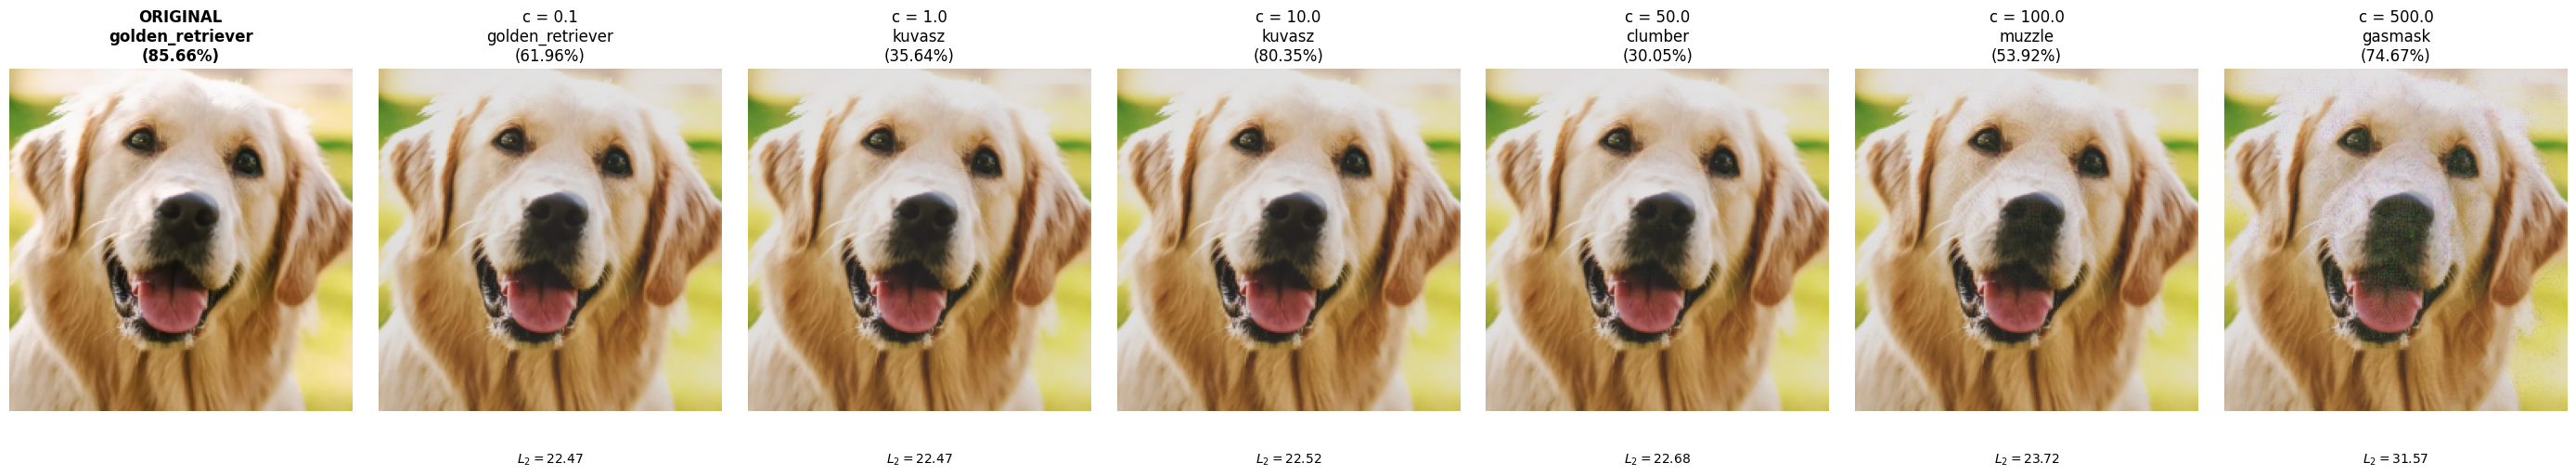

--- Target Image: Lion ---


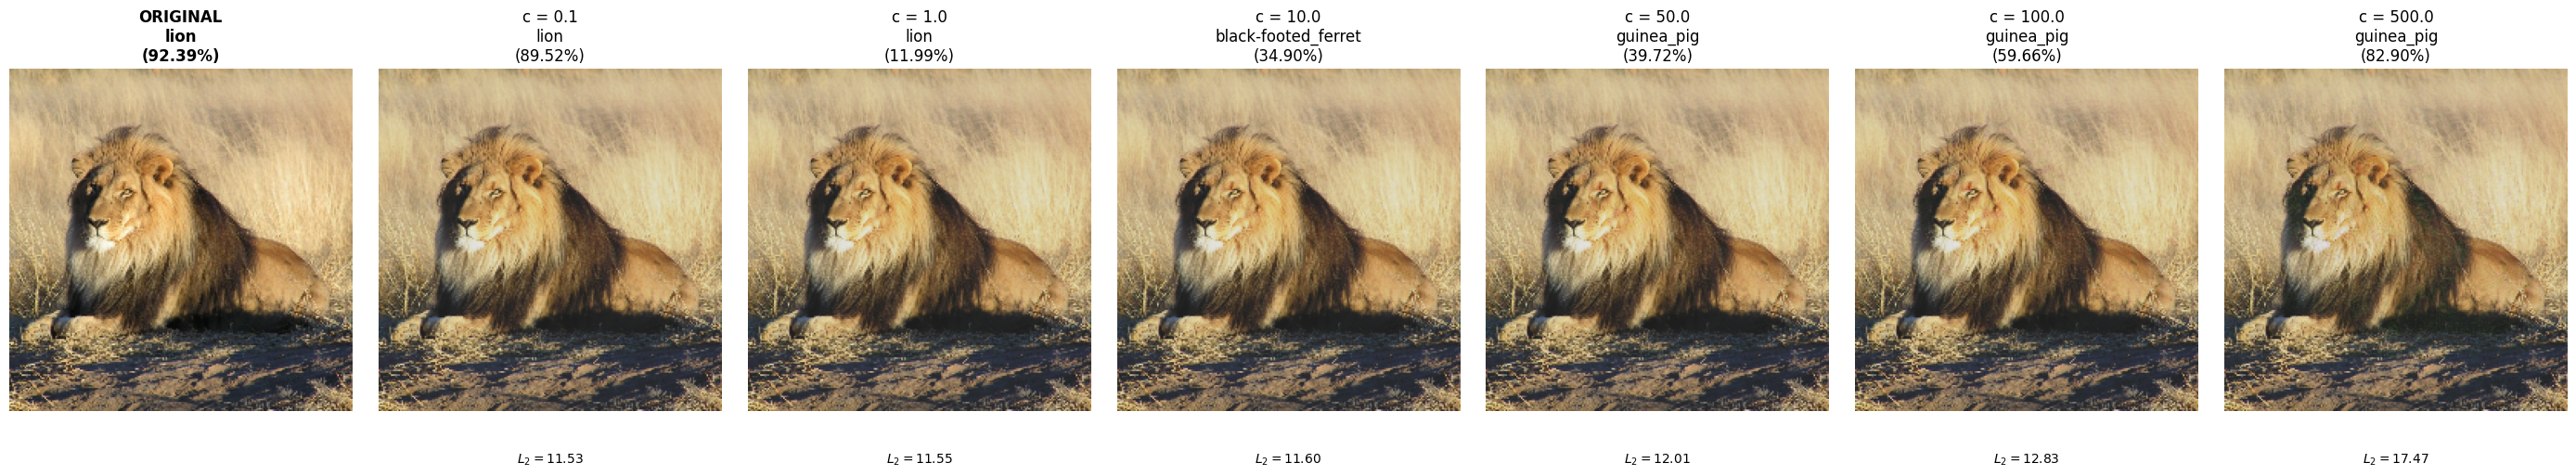


EXECUTING C&W ATTACKS ON MODEL: EfficientNetB0

--- Target Image: Dog ---


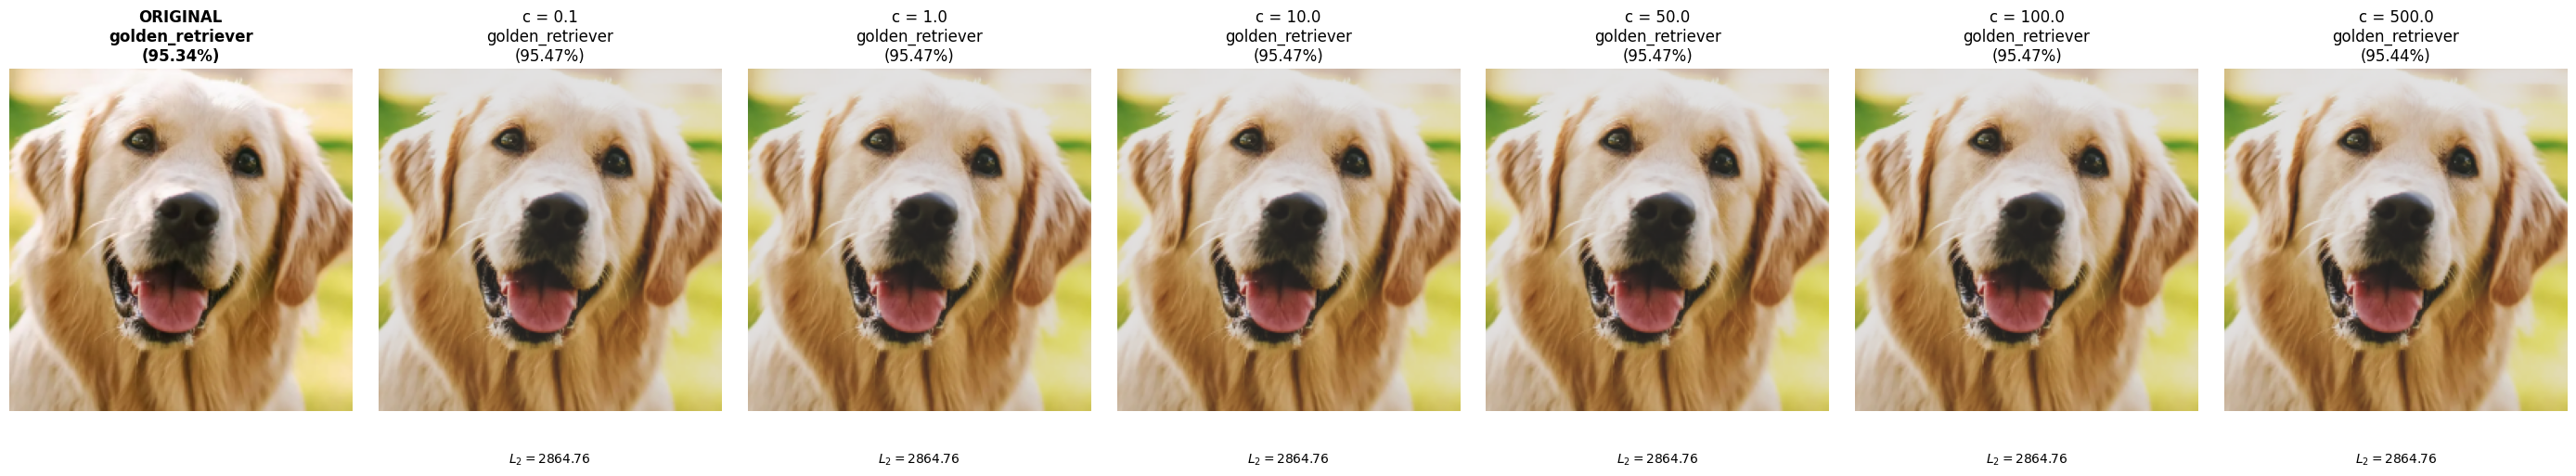

--- Target Image: Lion ---


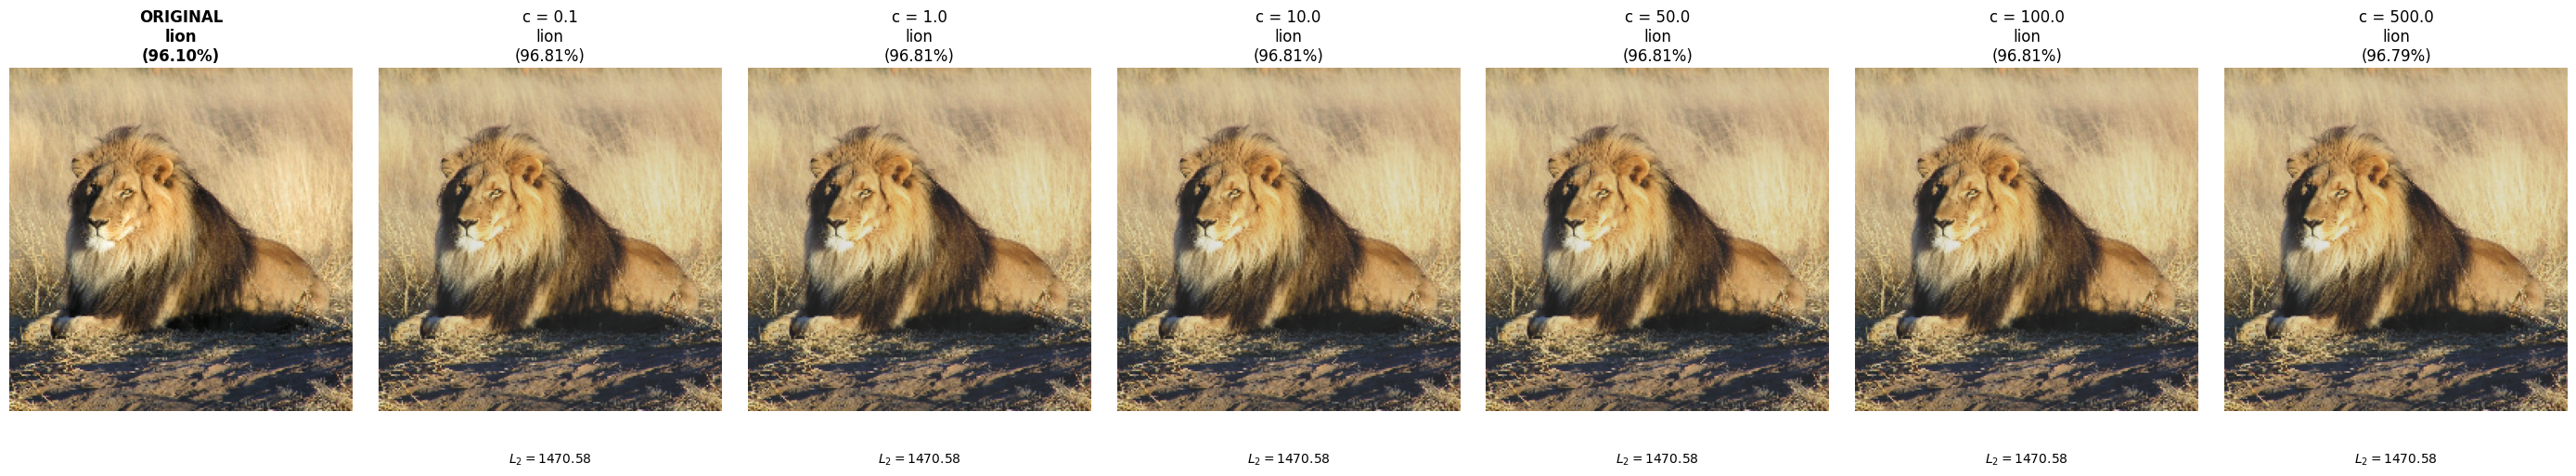


EXECUTING C&W ATTACKS ON MODEL: InceptionV3

--- Target Image: Dog ---


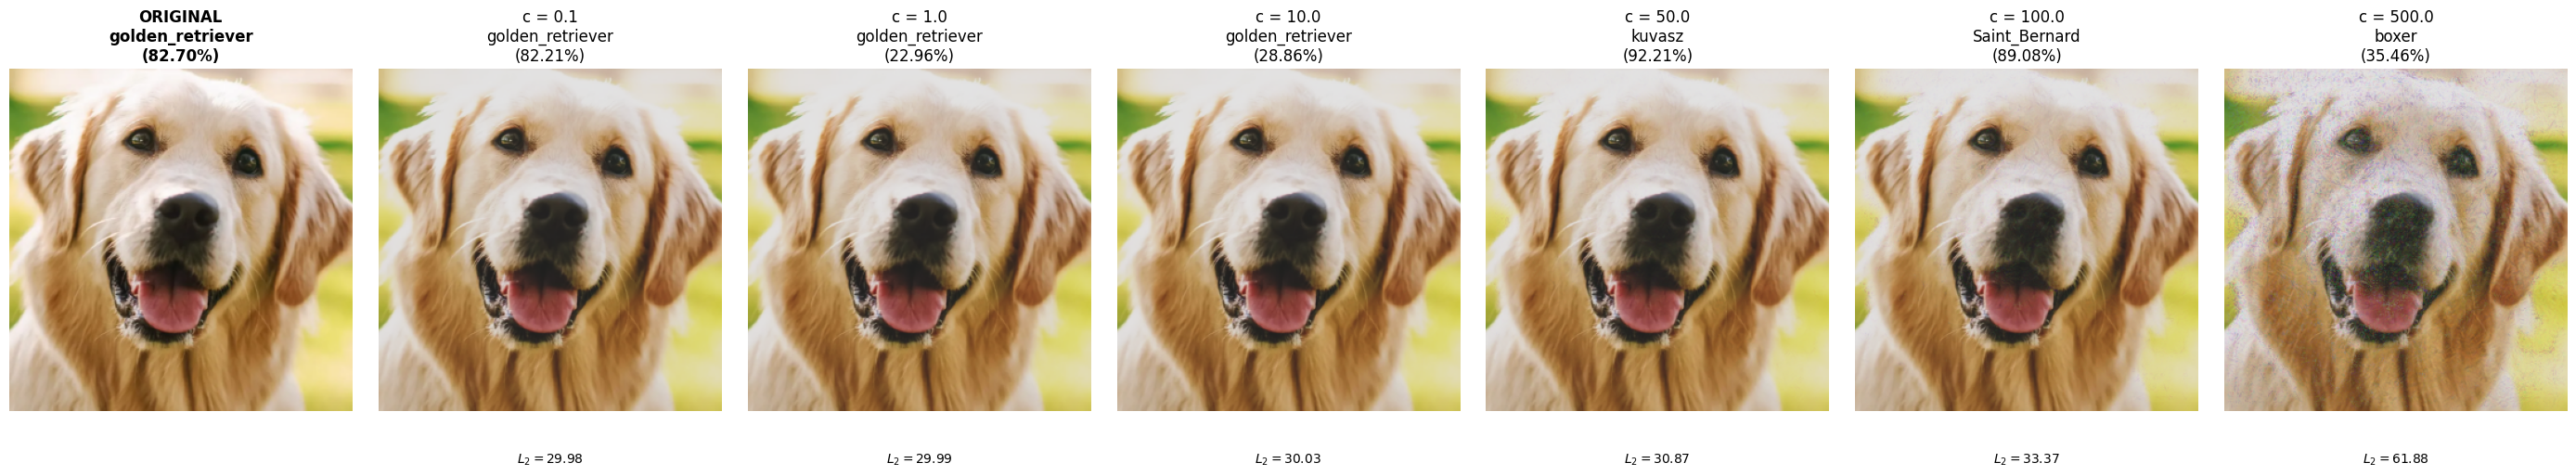

--- Target Image: Lion ---


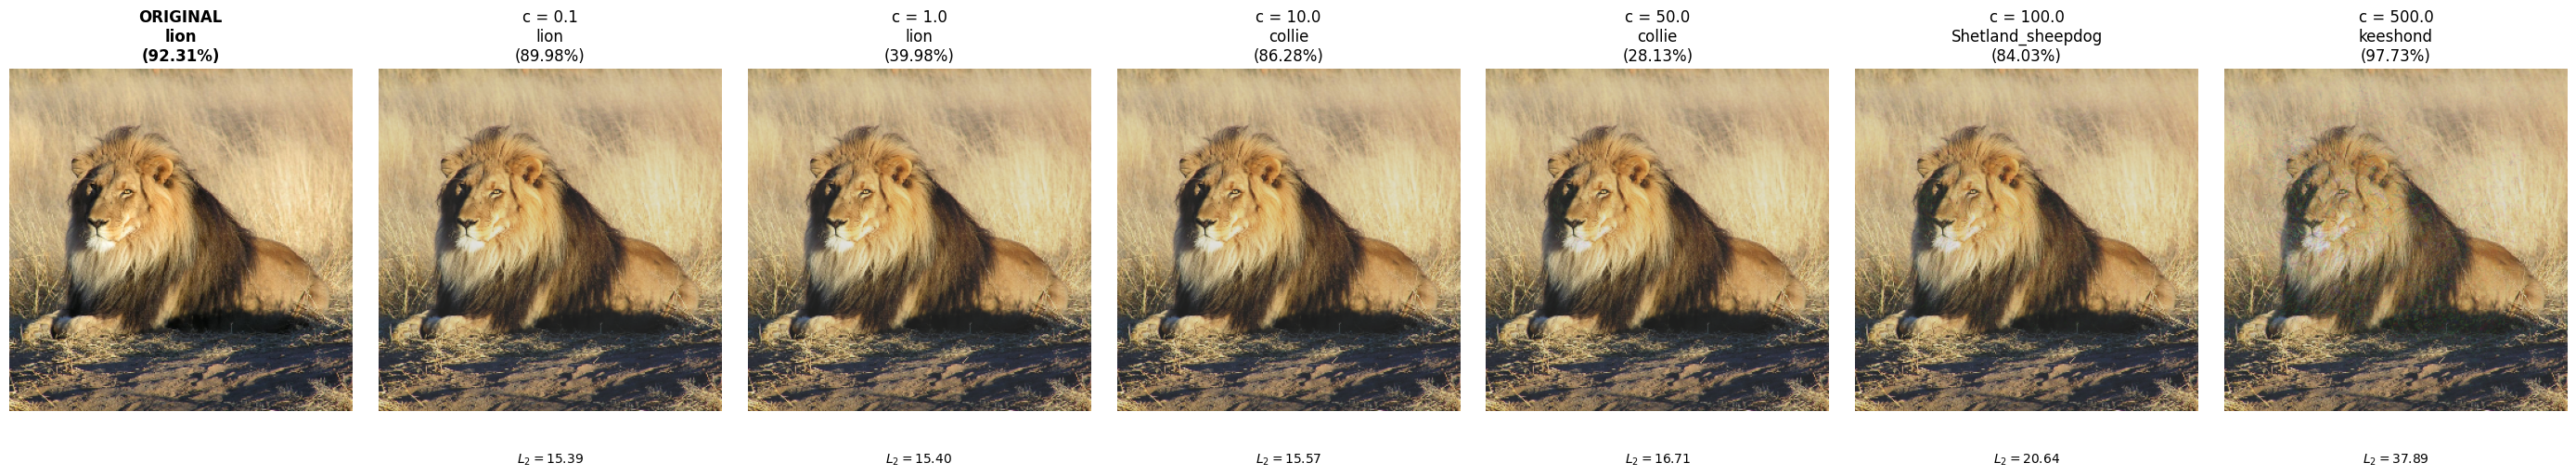

In [5]:
# In C&W, we iterate over 'c' values instead of epsilons
c_values = [0.1, 1.0, 10.0, 50.0, 100.0, 500.0]
num_cols = len(c_values) + 1 # +1 to include the original image as a baseline

for model_name, m_config in models_dict.items():
    # Print a clear header when switching models
    print(f"\n{'='*80}")
    print(f"EXECUTING C&W ATTACKS ON MODEL: {model_name}")
    print(f"{'='*80}\n")
    
    current_model = m_config['model']
    target_size = m_config['target_size']
    preprocess_fn = m_config['preprocess_fn']
    decode_fn = m_config['decode_fn']
    denormalize_fn = m_config['denormalize_fn'] # Dynamic denormalization function
    
    # Specific C&W box constraints
    box_min = m_config['box_min']
    box_max = m_config['box_max']
    
    for img_name, img_path in images_dict.items():
        print(f"--- Target Image: {img_name} ---")
        
        # Create a new figure for this specific model and image (1 row, 7 columns)
        fig, axes = plt.subplots(1, num_cols, figsize=(4 * num_cols, 4.5))
        fig.subplots_adjust(wspace=0.1)
        
        # Load and Preprocess
        input_img = load_and_preprocess_image(img_path, target_size, preprocess_fn)
        
        # Get Original Prediction
        original_probs = current_model.predict(input_img, verbose=0)
        _, orig_class_name, orig_prob = get_imagenet_label(original_probs, decode_fn)
        
        # Create One-Hot label
        class_idx = get_imagenet_class_index(original_probs)
        input_label = tf.one_hot(class_idx, original_probs.shape[-1])
        input_label = tf.reshape(input_label, (1, original_probs.shape[-1]))
        
        # Plot Original Image in the first column
        ax_orig = axes[0]
        ax_orig.imshow(denormalize_fn(input_img)) # Apply specific denormalization
        ax_orig.set_title(f'ORIGINAL\n{orig_class_name}\n({orig_prob * 100:.2f}%)', fontweight='bold')
        ax_orig.axis('off')
        
        # Iterate over 'c' values
        for col_idx, c_val in enumerate(c_values, start=1):
            
            # Execute C&W Attack
            adv_img = cw_attack(input_img, input_label, current_model, box_min, box_max, c_weight=c_val, max_iters=200) 
            
            # Calculate L2 Distance
            l2 = euclidean_distance(input_img, adv_img)
            
            # Get Adversarial Prediction
            adv_img_probs = current_model.predict(adv_img, verbose=0)
            _, adv_img_class, adv_class_prob = get_imagenet_label(adv_img_probs, decode_fn)
            
            # Plot Adversarial Image
            ax = axes[col_idx]
            ax.imshow(denormalize_fn(adv_img)) 
            ax.set_title(f'c = {c_val}\n{adv_img_class}\n({adv_class_prob * 100:.2f}%)')
            ax.text(0.5, -0.15, f'$L_2={l2:.2f}$', transform=ax.transAxes, ha='center', fontsize=10)
            ax.axis('off')
            
        plt.tight_layout()
        plt.show()